# Dataset Splitting Visualization

This notebook visualizes the train, validation, and test datasets produced by `src/preprocessing/split.py`.

The goal is to verify this preprocessing phase only:

- `data/encoded_data.csv` was split into train, validation, and test files
- Split sizes follow the documented `70% / 15% / 15%` ratio
- Target class distribution is preserved with stratified splitting

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', 100)

## 2. Load Split Data

In [2]:
paths = {
    'train': '../data/split/train_data.csv',
    'validation': '../data/split/validation_data.csv',
    'test': '../data/split/test_data.csv',
}

# Use samples for fast notebook visualization. Row counts are calculated from loaded samples here.
# Remove nrows if you want to inspect the full split files interactively.
splits = {
    name: pd.read_csv(path, nrows=250_000, low_memory=False)
    for name, path in paths.items()
}

for name, split_df in splits.items():
    print(f'{name}: {split_df.shape[0]:,} rows x {split_df.shape[1]} columns')

train: 250,000 rows x 56 columns
validation: 250,000 rows x 56 columns
test: 250,000 rows x 56 columns


In [3]:
splits['train'].head()

,gh_project_name,gh_is_pr,gh_pr_created_at,gh_pull_req_num,gh_lang,git_merged_with,git_branch,git_prev_commit_resolution_status,tr_prev_build,gh_team_size,git_num_all_built_commits,gh_num_issue_comments,gh_num_commit_comments,gh_num_pr_comments,git_diff_src_churn,git_diff_test_churn,gh_diff_files_added,gh_diff_files_deleted,gh_diff_files_modified,gh_diff_tests_added,gh_diff_tests_deleted,gh_diff_src_files,gh_diff_doc_files,gh_diff_other_files,gh_num_commits_on_files_touched,gh_sloc,gh_test_lines_per_kloc,gh_test_cases_per_kloc,gh_asserts_cases_per_kloc,gh_by_core_team_member,gh_build_started_at,gh_repo_age,gh_repo_num_commits,tr_build_number,tr_log_lan,tr_log_status,tr_log_analyzer,tr_log_frameworks,tr_log_bool_tests_ran,tr_log_bool_tests_failed,tr_log_num_tests_ok,tr_log_num_tests_failed,tr_log_num_tests_run,tr_log_num_tests_skipped,tr_log_testduration,tr_duration,tr_status,hour_of_day,day_of_week,is_weekend,total_code_churn,test_to_src_ratio,total_files_changed,is_large_commit,test_fail_ratio,project_failure_rate
0,vispy/vispy,1,2015-08-11 17:31:21,1049.0,2,commits_in_master,master,merge_found,0.0,18,7,111.0,0,83.0,0,0,0,0,11,0,0,0,0,11,343,37888,130.463471,4.513302,27.422931,1,2016-02-21 06:44:24,1066.00,5191,3933,python,broken,python,pytest,1,False,188.0,0.0,188.0,15.0,15.62,3967.0,1,6,6,1,0,0.0,11,0,0.0,0.328036
1,nipy/dipy,1,2016-06-23 12:50:24,1087.0,2,merge_button,master,build_found,151752044.0,27,18,6.0,0,4.0,0,0,11,8,22,0,0,0,0,29,432,20806,556.329905,20.042295,95.597424,0,2016-08-30 15:19:36,2523.59,6106,4160,python,ok,python,unittest,1,False,614.0,0.0,614.0,27.0,931.55,17774.0,0,15,1,0,0,0.0,41,0,0.0,0.086512
2,mongodb/mongo-ruby-driver,1,2014-02-24 22:00:17,368.0,3,unknown,1.x-stable,build_found,19500417.0,10,3,2.0,0,8.0,0,0,0,0,7,0,0,0,0,7,85,6568,1717.113276,149.512789,420.980512,1,2014-02-25 22:06:08,1921.88,2699,1363,java,ok,java-ant,unknown,0,unknown,0.0,0.0,0.0,0.0,0.00,3029.0,0,22,1,0,0,0.0,7,0,0.0,0.186694
3,rspec/rspec-mocks,1,2013-04-02 04:10:29,264.0,3,merge_button,master,build_found,10230332.0,18,1,4.0,0,0.0,0,0,0,0,1,0,0,0,0,1,11,2762,2171.252715,263.577118,535.119479,1,2013-08-15 16:59:47,1508.05,1106,1036,ruby,ok,ruby,rspec#cucumber,1,False,1916.0,0.0,1916.0,6.0,127.48,2665.0,0,16,3,0,0,0.0,1,0,0.0,0.149790
4,puma/puma,0,unknown,0.0,3,unknown,master,merge_found,0.0,6,1,0.0,0,0.0,0,0,0,0,1,0,0,0,0,1,29,4227,403.359357,27.915780,54.412113,1,2015-11-06 18:48:26,3568.96,1923,857,ruby,ok,ruby,unknown,0,unknown,0.0,0.0,0.0,0.0,0.00,2107.0,1,18,4,0,0,0.0,1,0,0.0,0.589987


## 3. Full Split Row Counts

In [4]:
def count_csv_rows(path):
    with open(path, 'r', encoding='utf-8') as file:
        return sum(1 for _ in file) - 1


row_counts = pd.DataFrame({
    'split': list(paths.keys()),
    'rows': [count_csv_rows(path) for path in paths.values()],
})
row_counts['percent'] = (row_counts['rows'] / row_counts['rows'].sum() * 100).round(2)

row_counts

,split,rows,percent
0,train,1956107,70.0
1,validation,419166,15.0
2,test,419166,15.0


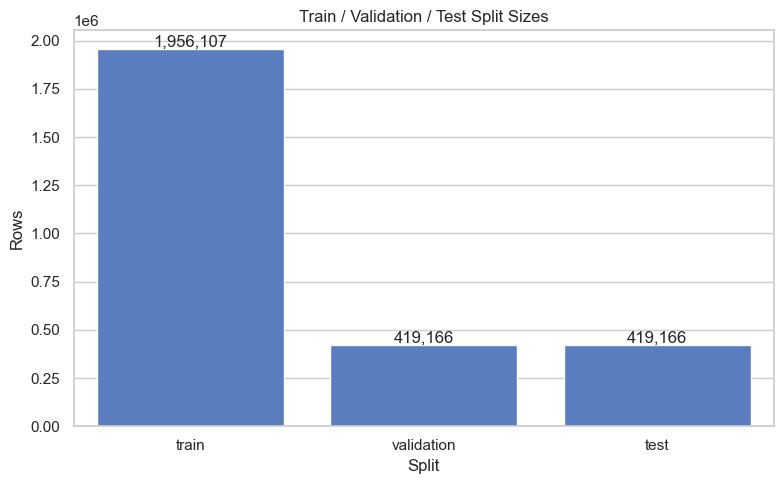

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=row_counts, x='split', y='rows')
ax.set_title('Train / Validation / Test Split Sizes')
ax.set_xlabel('Split')
ax.set_ylabel('Rows')

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

## 4. Target Distribution by Split

In [6]:
target_summary = []

for name, path in paths.items():
    target = pd.read_csv(path, usecols=['tr_status'], low_memory=False)['tr_status']
    counts = target.value_counts().reindex([0, 1], fill_value=0)
    total = counts.sum()

    target_summary.append({
        'split': name,
        'passed_0': counts.loc[0],
        'failure_1': counts.loc[1],
        'passed_percent': round(counts.loc[0] / total * 100, 2),
        'failure_percent': round(counts.loc[1] / total * 100, 2),
    })

target_summary = pd.DataFrame(target_summary)
target_summary

,split,passed_0,failure_1,passed_percent,failure_percent
0,train,1449766,506341,74.11,25.89
1,validation,310664,108502,74.11,25.89
2,test,310664,108502,74.11,25.89


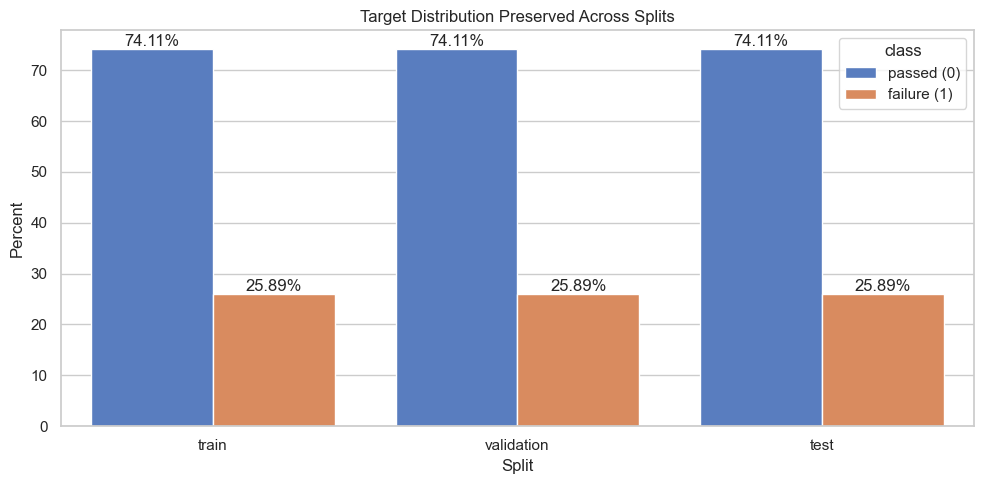

In [7]:
target_plot = target_summary.melt(
    id_vars='split',
    value_vars=['passed_percent', 'failure_percent'],
    var_name='class',
    value_name='percent',
)
target_plot['class'] = target_plot['class'].map({
    'passed_percent': 'passed (0)',
    'failure_percent': 'failure (1)',
})

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=target_plot, x='split', y='percent', hue='class')
ax.set_title('Target Distribution Preserved Across Splits')
ax.set_xlabel('Split')
ax.set_ylabel('Percent')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

## 5. Feature Consistency Check

In [8]:
columns_by_split = {name: set(split_df.columns) for name, split_df in splits.items()}
reference_columns = columns_by_split['train']

column_check = pd.DataFrame({
    'split': list(columns_by_split.keys()),
    'same_columns_as_train': [cols == reference_columns for cols in columns_by_split.values()],
    'column_count': [len(cols) for cols in columns_by_split.values()],
})

column_check

,split,same_columns_as_train,column_count
0,train,True,56
1,validation,True,56
2,test,True,56


## 6. Key Feature Distribution Comparison

In [9]:
key_features = [
    'tr_duration',
    'gh_team_size',
    'total_code_churn',
    'total_files_changed',
    'test_fail_ratio',
    'project_failure_rate',
]
key_features = [col for col in key_features if col in splits['train'].columns]

combined_sample = pd.concat(
    [split_df.assign(split=name) for name, split_df in splits.items()],
    ignore_index=True,
)

combined_sample[key_features + ['split']].head()

,tr_duration,gh_team_size,total_code_churn,total_files_changed,test_fail_ratio,project_failure_rate,split
0,3967.0,18,0,11,0.0,0.328036,train
1,17774.0,27,0,41,0.0,0.086512,train
2,3029.0,10,0,7,0.0,0.186694,train
3,2665.0,18,0,1,0.0,0.149790,train
4,2107.0,6,0,1,0.0,0.589987,train


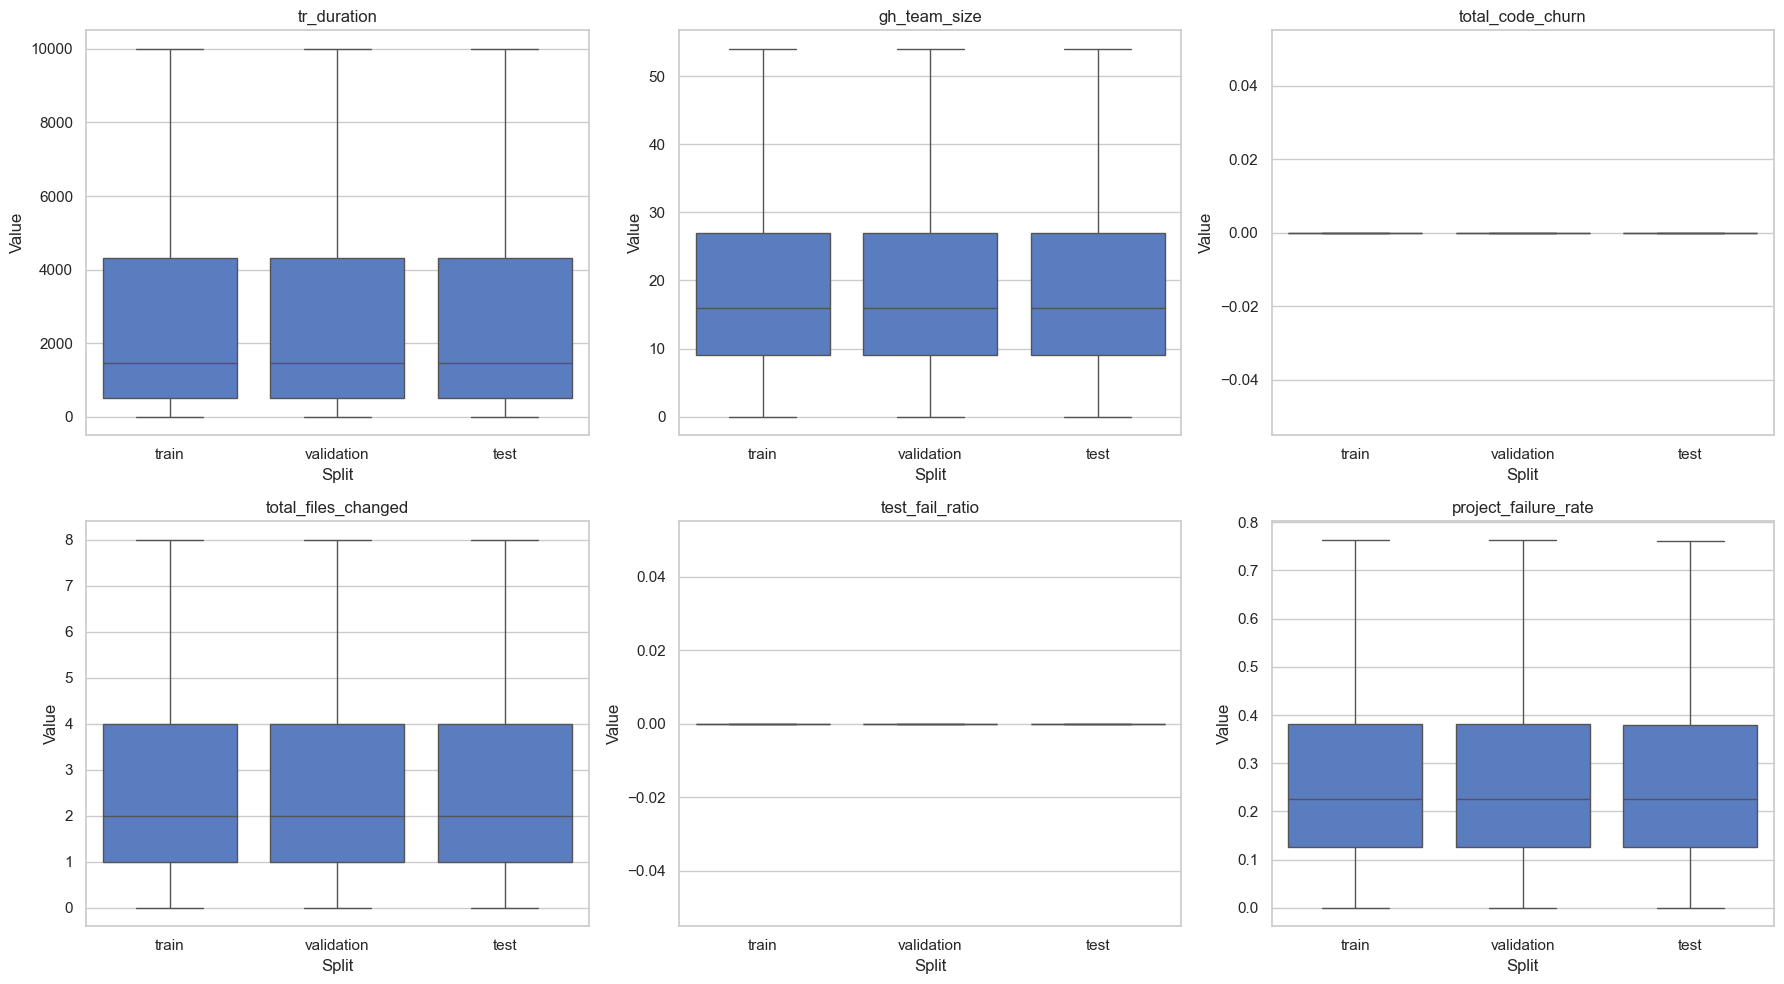

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, key_features):
    sns.boxplot(data=combined_sample, x='split', y=col, ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel('Split')
    ax.set_ylabel('Value')

for ax in axes[len(key_features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Missing Values by Split

In [11]:
missing_summary = []

for name, split_df in splits.items():
    missing_summary.append({
        'split': name,
        'missing_cells': int(split_df.isna().sum().sum()),
        'total_cells': int(split_df.shape[0] * split_df.shape[1]),
    })

missing_summary = pd.DataFrame(missing_summary)
missing_summary['missing_percent'] = (
    missing_summary['missing_cells'] / missing_summary['total_cells'] * 100
).round(4)

missing_summary

,split,missing_cells,total_cells,missing_percent
0,train,0,14000000,0.0
1,validation,0,14000000,0.0
2,test,0,14000000,0.0


## Summary

The split phase creates three datasets under `data/split/` while preserving the target distribution.

**Next step:** `src/preprocessing/scale_balance.py` - scale split datasets and balance the training set only.